# TS7 - Estimacion espectral: Ancho de banda de senales reales
Establecer plantilla de diseno

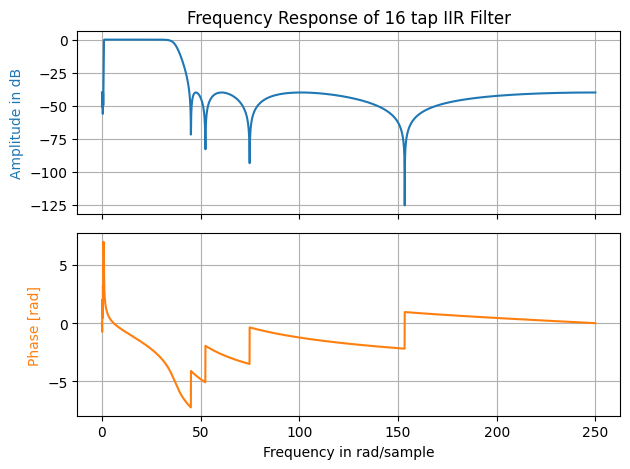

In [22]:
# Pasa Banda

from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp1 = 1
ws1 = 0.1
wp2 = 35
ws2 = 45
gpass = 1 #dB => lo bajamos
gstop = 40 #dB => Lo subimos

fs = 500

wp = [wp1, wp2] # banda de paso:  ws1 < wp1 < wp2 < ws2
ws = [ws1, ws2] # banda de stop

#ftype="butter"
#ftype="cheby1"
ftype="cheby2"
#ftype="cauer"

sos_coef = signal.iirdesign(wp, ws, gpass, gstop, analog=False, ftype=ftype, output='sos', fs=fs)

taps = sos_coef.shape[0] * 2

omega, resp_freq = signal.freqz_sos(sos_coef, worN=4096, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()


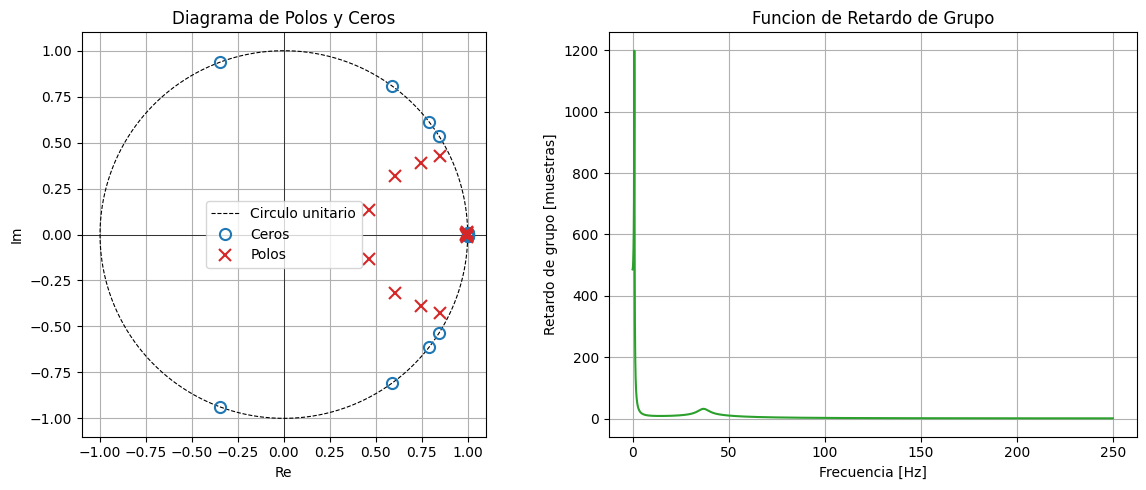

In [23]:
# Diagrama de Polos y Ceros + Funcion de Retardo de Grupo

zeros, poles, gain = signal.sos2zpk(sos_coef)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), tight_layout=True)

# Polos y Ceros
ax_pz = axs[0]
ax_pz.set_title("Diagrama de Polos y Ceros")

theta = np.linspace(0, 2 * np.pi, 512)
ax_pz.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, label='Circulo unitario')
ax_pz.axhline(0, color='k', linewidth=0.5)
ax_pz.axvline(0, color='k', linewidth=0.5)

ax_pz.plot(zeros.real, zeros.imag, 'C0o', markersize=8, label='Ceros', markerfacecolor='none', markeredgewidth=1.5)
ax_pz.plot(poles.real, poles.imag, 'C3x', markersize=8, label='Polos', markeredgewidth=1.5)

ax_pz.set_xlabel("Re")
ax_pz.set_ylabel("Im")
ax_pz.set_aspect('equal')
ax_pz.legend()
ax_pz.grid(True)

# Retardo de Grupo
ax_gd = axs[1]
ax_gd.set_title("Funcion de Retardo de Grupo")

N_w = 4096
gd_total = np.zeros(N_w)
for section in sos_coef:
    b_sec = section[:3]
    a_sec = section[3:]
    omega_gd, gd_sec = signal.group_delay((b_sec, a_sec), w=N_w, fs=fs)
    gd_total += gd_sec

ax_gd.plot(omega_gd, gd_total, 'C2')
ax_gd.set_xlabel("Frecuencia [Hz]")
ax_gd.set_ylabel("Retardo de grupo [muestras]")
ax_gd.set_xlim(0, fs / 2)
ax_gd.axis('tight')
ax_gd.grid(True)

plt.show()


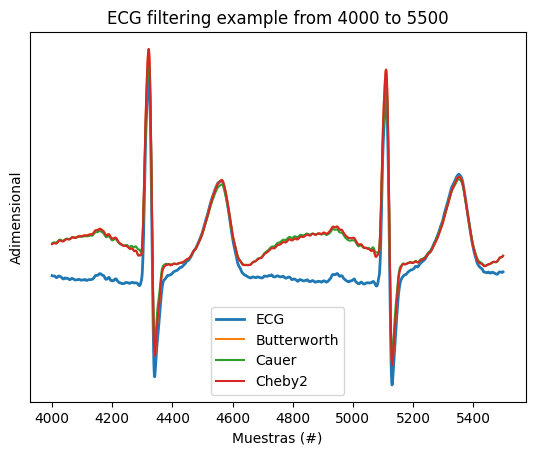

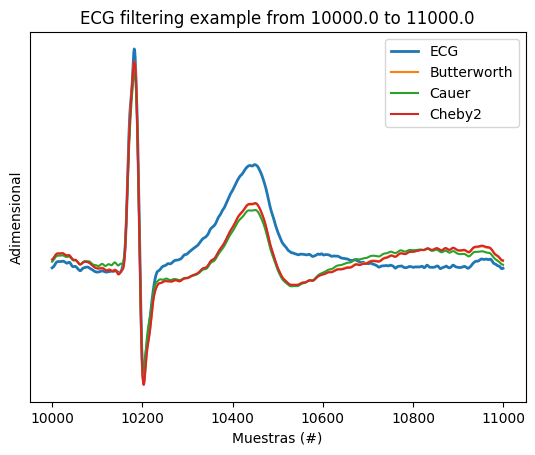

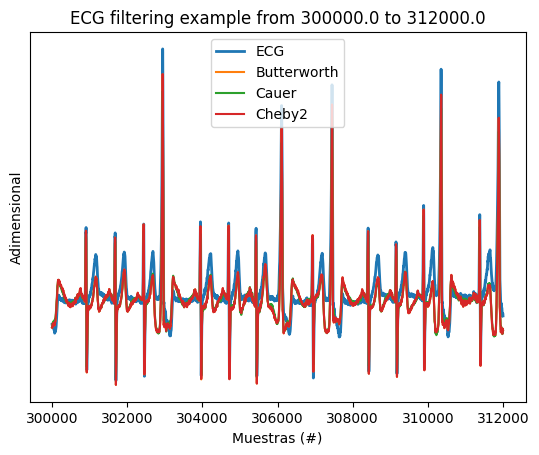

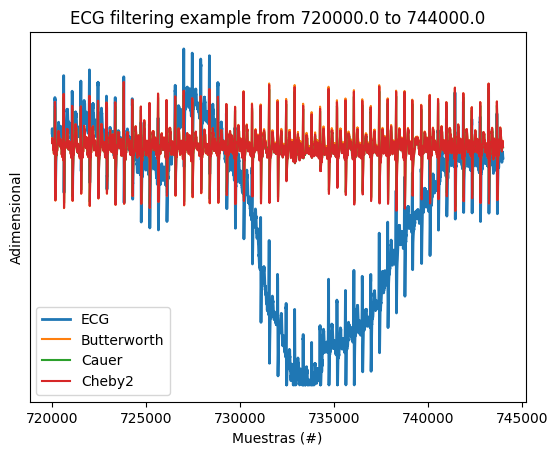

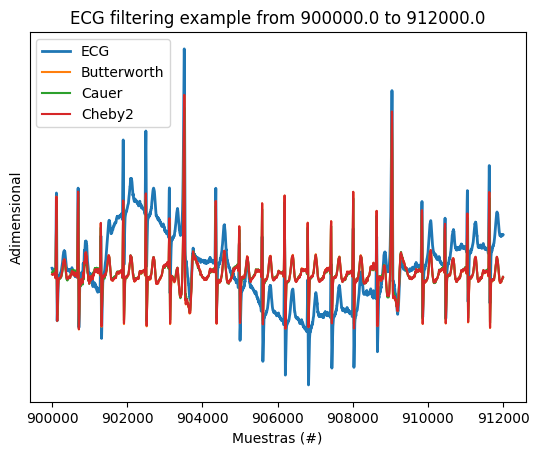

In [24]:
import scipy.io as sio

fs_ecg = 1000  # Hz

mat_struct    = sio.loadmat(r'C:\Users\MSI\Desktop\ECG_TP4.mat')
ecg_one_lead  = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

# gpass/2 y gstop/2 porque sosfiltfilt aplica el filtro dos veces (forward + backward)
sos_but    = signal.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='butter', output='sos', fs=fs)
sos_cauer  = signal.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='cauer',  output='sos', fs=fs)
sos_cheby2 = signal.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='cheby2', output='sos', fs=fs)

# Filtrar con sosfiltfilt (fase cero, sin retardo)
ECG_f_butt   = signal.sosfiltfilt(sos_but,    ecg_one_lead)
ECG_f_cauer  = signal.sosfiltfilt(sos_cauer,  ecg_one_lead)
ECG_f_cheby2 = signal.sosfiltfilt(sos_cheby2, ecg_one_lead)

###################################
# Regiones de interés con ruido   #
###################################

regs_interes = (
    [4000, 5500],   # muestras
    [10e3, 11e3],   # muestras
)

for ii in regs_interes:
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG',         linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region],   label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region],  label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()

###################################
# Regiones de interés sin ruido   #
###################################

regs_interes = (
    np.array([5,   5.2]) * 60 * fs_ecg,   # minutos a muestras
    np.array([12, 12.4]) * 60 * fs_ecg,
    np.array([15, 15.2]) * 60 * fs_ecg,
)

for ii in regs_interes:
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG',         linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region],   label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region],  label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()


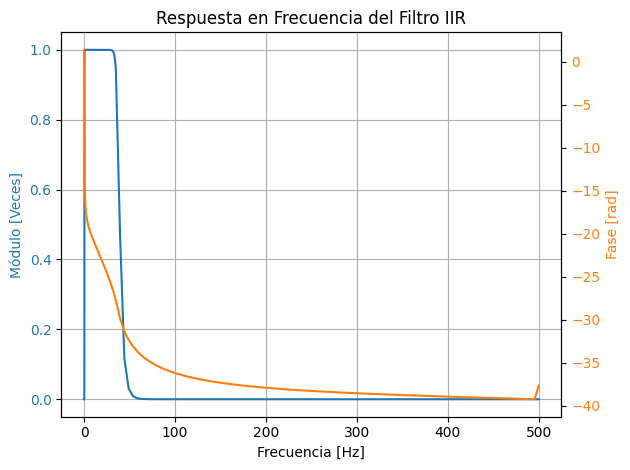

C:\Users\MSI\AppData\Local\Temp\ipykernel_6484\3491052605.py:59: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(w, 20 * np.log10(abs(h)), 'b')


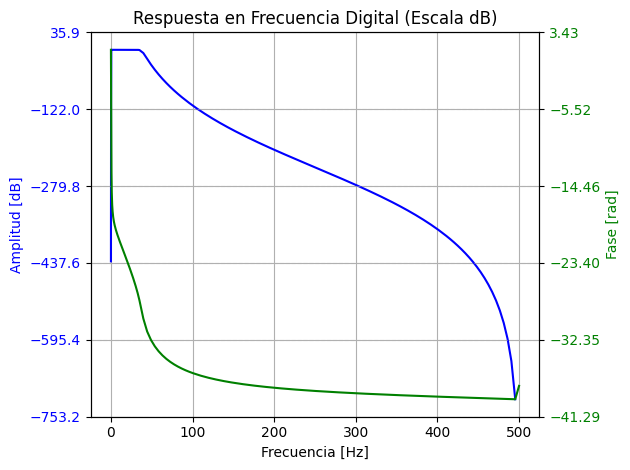

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


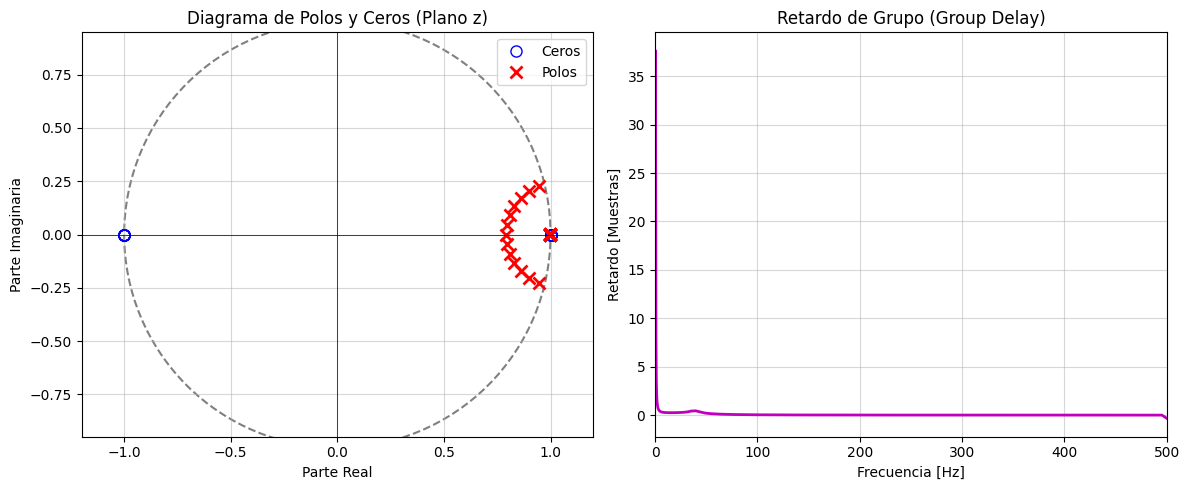

C:\Users\MSI\AppData\Local\Temp\ipykernel_6484\3491052605.py:120: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(w, 20 * np.log10(np.abs(h)), 'b', linewidth=1.8, label='Filtro diseñado')


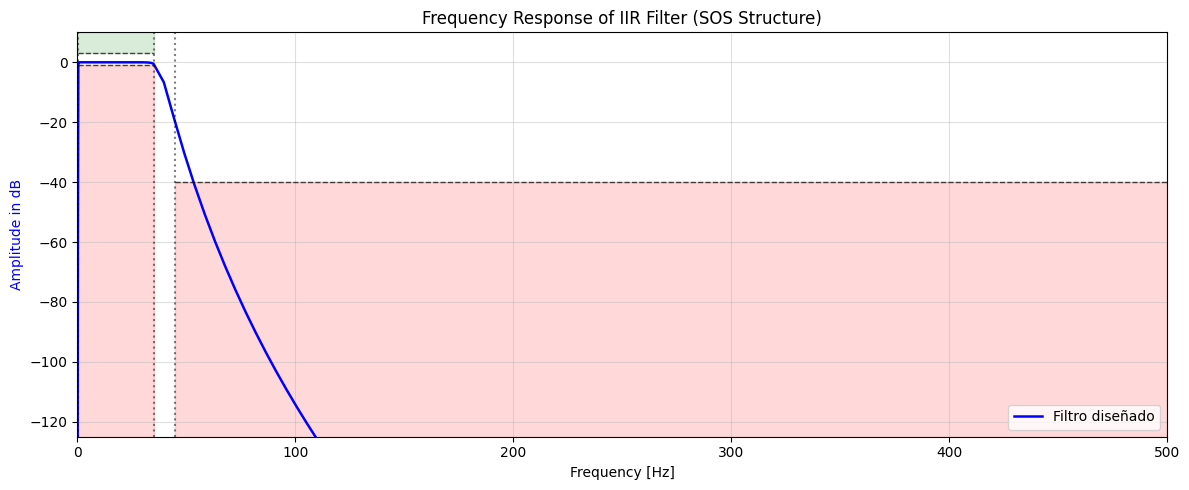

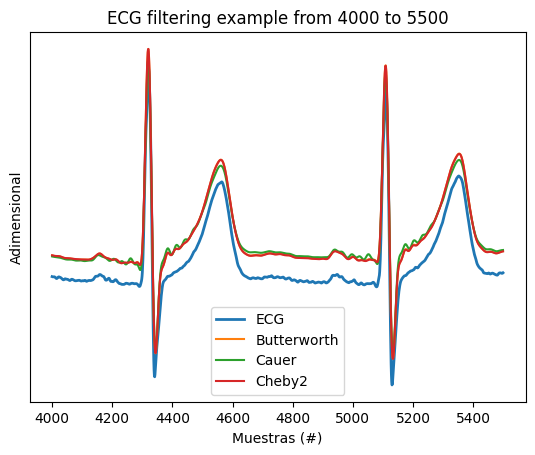

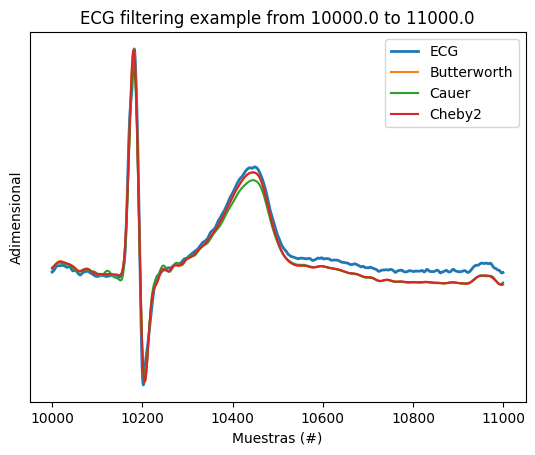

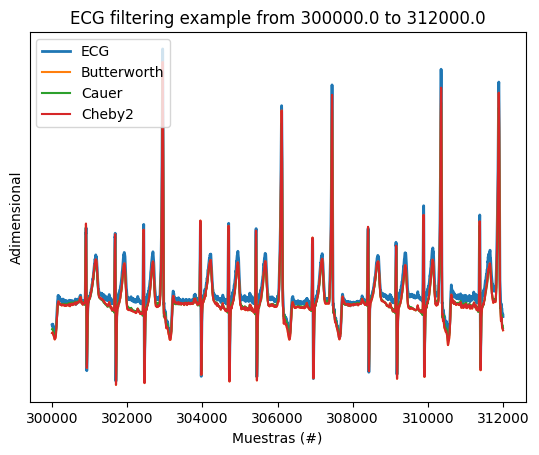

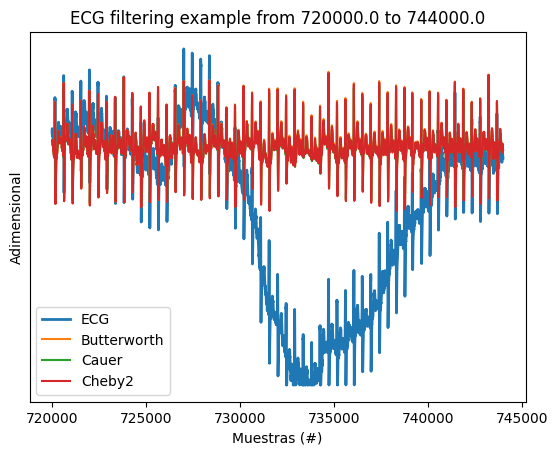

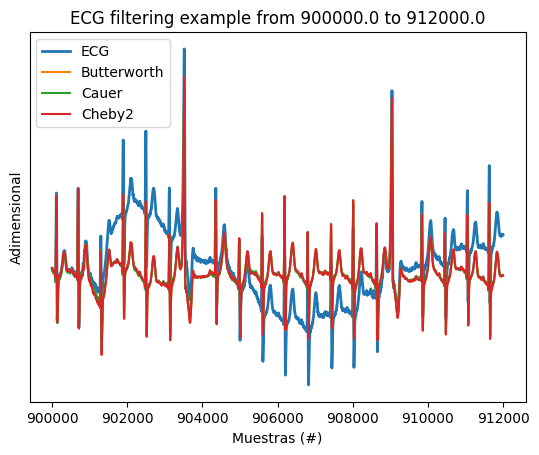

In [25]:
import matplotlib.ticker as ticker
import scipy.io as sio

# ================================================================
# Diseno del filtro (fs = 1000 Hz, igual que ECG)
# ================================================================
fs    = 1000
gpass = 1
gstop = 40
ws1   = 0.05
wp1   = 0.5
ws2   = 45
wp2   = 35

wp = [wp1, wp2]
ws = [ws1, ws2]

# gpass/2 y gstop/2: sosfiltfilt aplica el filtro dos veces, duplicando la atenuacion
sos_but    = signal.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='butter',  output='sos', fs=fs)
sos_cauer  = signal.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='cauer',   output='sos', fs=fs)
sos_cheby2 = signal.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='cheby2',  output='sos', fs=fs)

sos = sos_but  # filtro activo para los graficos de respuesta

# Vector de frecuencias con alta densidad en bandas de transicion
ww = np.concatenate([
    np.logspace(start=-2, stop=np.log10(wp1), num=500),
    np.linspace(start=wp1, stop=wp2, num=200),
    np.linspace(start=wp2, stop=fs/2, num=100),
])
ww = np.sort(np.unique(ww))

w, h   = signal.sosfreqz(sos, worN=ww, fs=fs)
phase  = np.unwrap(np.angle(h))

# ================================================================
# Respuesta en frecuencia: Modulo (veces) y Fase
# ================================================================
fig, ax1 = plt.subplots(tight_layout=True)
ax1.set_title("Respuesta en Frecuencia del Filtro IIR")
ax1.plot(w, abs(h), 'C0', label='Módulo')
ax1.set_ylabel("Módulo [Veces]", color='C0')
ax1.set_xlabel("Frecuencia [Hz]")
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(w, phase, 'C1', label='Fase')
ax2.set_ylabel('Fase [rad]', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

plt.show()

# ================================================================
# Respuesta en frecuencia: Escala dB + Fase desenvuelta
# ================================================================
fig, ax1 = plt.subplots(tight_layout=True)
ax1.set_title('Respuesta en Frecuencia Digital (Escala dB)')
ax1.plot(w, 20 * np.log10(abs(h)), 'b')
ax1.set_ylabel('Amplitud [dB]', color='b')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(w, phase, 'g')
ax2.set_ylabel('Fase [rad]', color='g')
ax2.tick_params(axis='y', labelcolor='g')

nticks = 6
ax1.yaxis.set_major_locator(ticker.LinearLocator(nticks))
ax2.yaxis.set_major_locator(ticker.LinearLocator(nticks))
ax2.grid(True, linestyle='--', alpha=0.5)

plt.show()

# ================================================================
# Diagrama de Polos y Ceros (Plano z) + Retardo de Grupo
# ================================================================
fig_sys = plt.figure(figsize=(12, 5), tight_layout=True)

# Panel izquierdo: Plano Z
ax_z = fig_sys.add_subplot(1, 2, 1)
ceros, polos, k = signal.sos2zpk(sos)

circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.5)
ax_z.add_artist(circulo)
ax_z.plot(np.real(ceros), np.imag(ceros), 'bo', markersize=8, fillstyle='none', label='Ceros')
ax_z.plot(np.real(polos), np.imag(polos), 'rx', markersize=8, mew=2,            label='Polos')
ax_z.axhline(0, color='black', linewidth=0.5)
ax_z.axvline(0, color='black', linewidth=0.5)
ax_z.set_title('Diagrama de Polos y Ceros (Plano z)')
ax_z.set_xlabel('Parte Real')
ax_z.set_ylabel('Parte Imaginaria')
ax_z.axis('equal')
ax_z.set_xlim([-1.2, 1.2])
ax_z.set_ylim([-1.2, 1.2])
ax_z.grid(True, alpha=0.5)
ax_z.legend()

# Panel derecho: Retardo de Grupo (derivada numerica de la fase)
ax_gd = fig_sys.add_subplot(1, 2, 2)
gd = -np.diff(phase) / np.diff(ww)
gd = np.append(gd[0], gd)
ax_gd.plot(ww, gd, 'm', linewidth=2)
ax_gd.set_title('Retardo de Grupo (Group Delay)')
ax_gd.set_xlabel('Frecuencia [Hz]')
ax_gd.set_ylabel('Retardo [Muestras]')
ax_gd.set_xlim(0, fs/2)
ax_gd.grid(True, alpha=0.5)

plt.show()

# ================================================================
# Respuesta en frecuencia con plantilla de diseno sombrada
# ================================================================
fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("Frequency Response of IIR Filter (SOS Structure)")

ax1.plot(w, 20 * np.log10(np.abs(h)), 'b', linewidth=1.8, label='Filtro diseñado')

piso_grafico  = -125
techo_grafico = 10

# Banda de parada 1 (0 a ws1)
ax1.fill_between([0,        ws1],     piso_grafico, -gstop,        color='red',   alpha=0.15)
ax1.plot(        [0,        ws1],     [-gstop,      -gstop],       'k--', linewidth=1, alpha=0.7)
# Zona inferior prohibida en banda de paso
ax1.fill_between([wp1,      wp2],     piso_grafico, -gpass,        color='red',   alpha=0.15)
ax1.plot(        [wp1,      wp2],     [-gpass,      -gpass],       'k--', linewidth=1, alpha=0.7)
# Zona superior prohibida en banda de paso (margen sobre 3 dB)
ax1.fill_between([wp1,      wp2],     3,             techo_grafico, color='green', alpha=0.15)
ax1.plot(        [wp1,      wp2],     [3,            3],            'k--', linewidth=1, alpha=0.7)
# Banda de parada 2 (ws2 a Nyquist)
ax1.fill_between([ws2,      fs/2],    piso_grafico, -gstop,        color='red',   alpha=0.15)
ax1.plot(        [ws2,      fs/2],    [-gstop,      -gstop],       'k--', linewidth=1, alpha=0.7)

ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel('Amplitude in dB', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_xlim(0, fs/2)
ax1.set_ylim([piso_grafico, techo_grafico])
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()

# ================================================================
# Carga y filtrado del ECG
# ================================================================
fs_ecg = 1000
mat_struct    = sio.loadmat(r'C:\Users\MSI\Desktop\ECG_TP4.mat')
ecg_one_lead  = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

ECG_f_butt   = signal.sosfiltfilt(sos_but,    ecg_one_lead)
ECG_f_cauer  = signal.sosfiltfilt(sos_cauer,  ecg_one_lead)
ECG_f_cheby2 = signal.sosfiltfilt(sos_cheby2, ecg_one_lead)

# ================================================================
# Regiones de interes sin ruido (por muestra)
# ================================================================
regs_interes = (
    [4000, 5500],
    [10e3, 11e3],
)

for ii in regs_interes:
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG',         linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region],   label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region],  label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()

# ================================================================
# Regiones de interes con ruido (por minuto)
# ================================================================
regs_interes = (
    np.array([5,   5.2]) * 60 * fs_ecg,
    np.array([12, 12.4]) * 60 * fs_ecg,
    np.array([15, 15.2]) * 60 * fs_ecg,
)

for ii in regs_interes:
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG',         linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region],   label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region],  label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()
